# Train and Tune Random Forest Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.random_forest import RandomForest
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.trials
SPLITS = cfg.runtime.splits
rng = set_seed(SEED)

2025-09-07 09:19:06,811 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "random_forest"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: RandomForest(horizon=horizon, random_state=seed),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=TRIALS, n_splits=SPLITS)

2025-09-07 09:19:06,857 - INFO - src.utils - Global random seed set to 42
2025-09-07 09:19:06,885 - INFO - ModelTrainer - Initialized trainer for random_forest
2025-09-07 09:23:10,737 - INFO - ModelTrainer - Initialized trainer for random_forest
2025-09-07 09:24:17,486 - INFO - ModelTrainer - Evaluating model...


In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

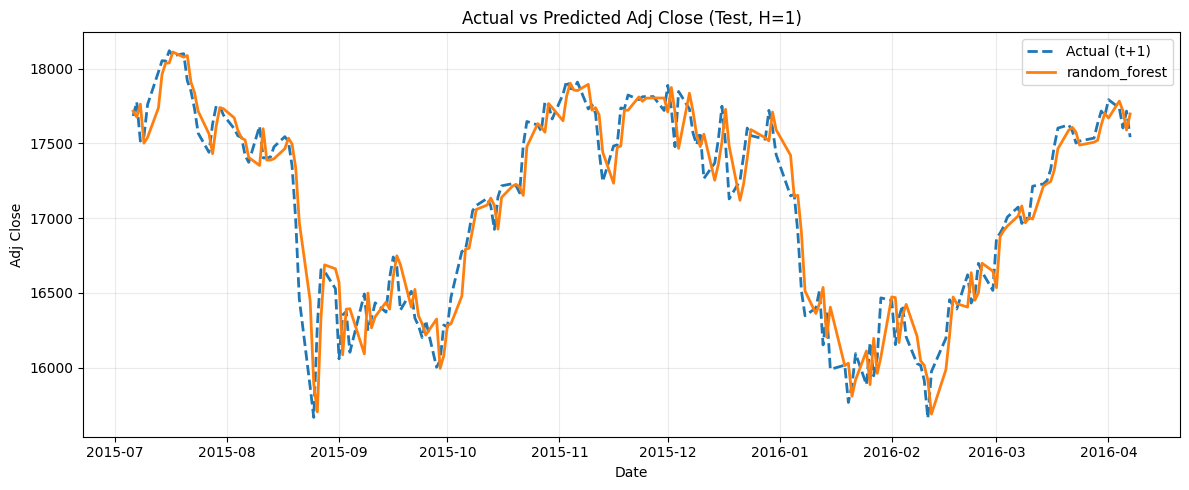

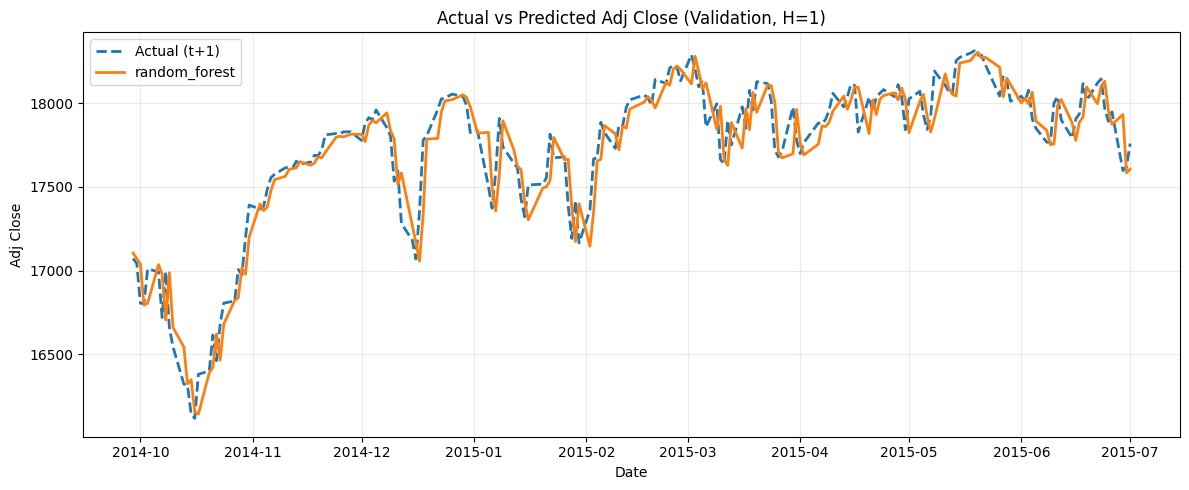

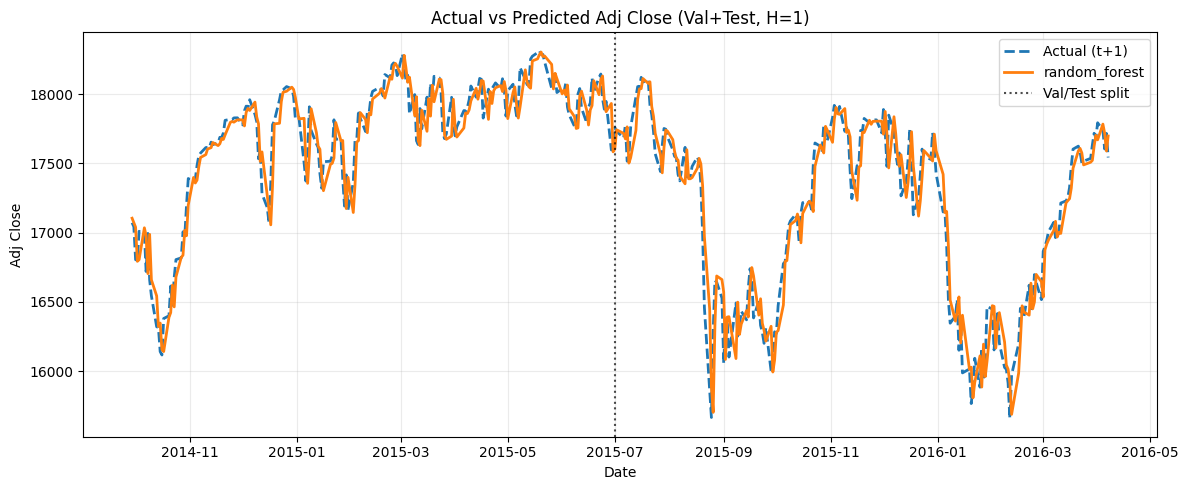

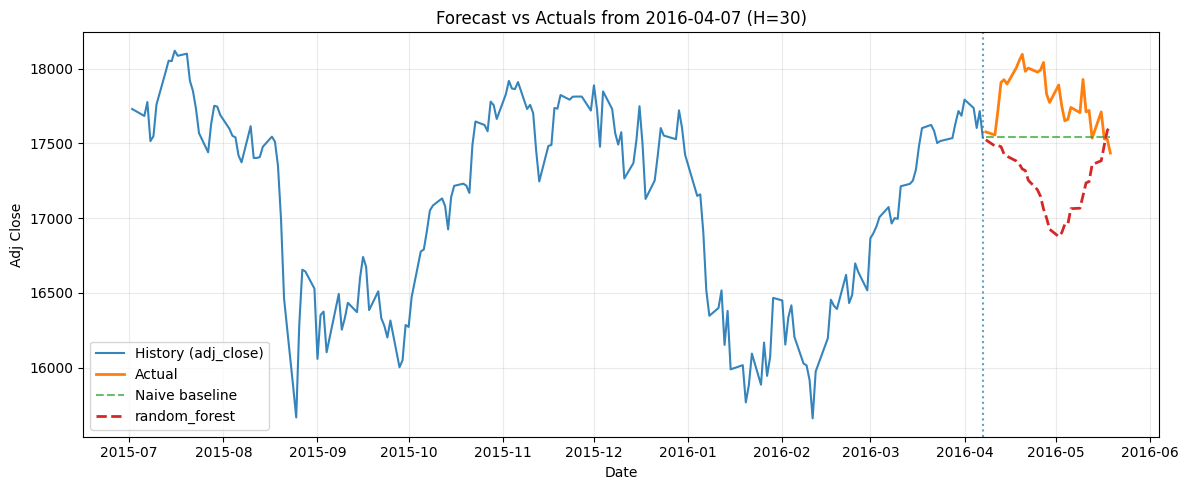

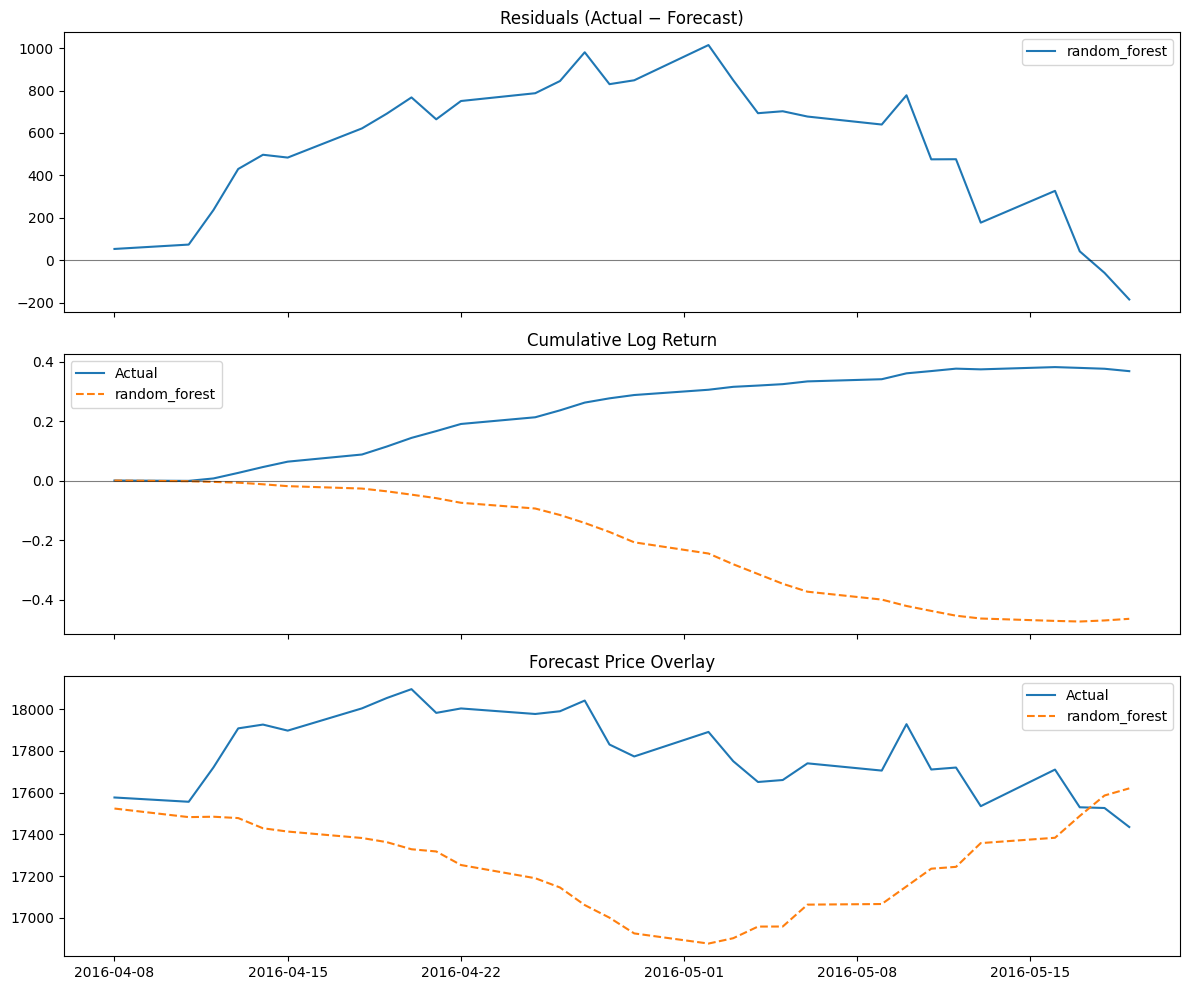

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [8]:
pd.DataFrame(results[0]["best_params"], index=[0])

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,max_samples,criterion,random_state
0,300,None,17,2,sqrt,False,None,absolute_error,42


In [9]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,541.386138,453715.481597,673.584057,1.441081,0.145695


In [10]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

In [11]:
from src.train import ModelTrainer
import pandas as pd
from pathlib import Path

model_path = Path(cfg.data.models_dir) / f"{MODEL_NAME}.pkl"
model, preprocessor, _, _ = ModelTrainer.load(str(model_path))

In [12]:
x_train_path = Path(cfg.data.processed_dir) / f"{MODEL_NAME}_X_train.parquet"
X_train = pd.read_parquet(x_train_path)

In [13]:
feat_names = preprocessor.get_feature_names_out(X_train.columns)
importances = pd.Series(model.model.feature_importances_, index=feat_names).sort_values(ascending=False)

In [14]:
def base_feature(n):
    tail = n.split("__")[-1]
    return tail.split("_", 1)[0]

grouped = importances.groupby(importances.index.map(base_feature)).sum().sort_values(ascending=False)
print(grouped.head(20))

emb       0.395112
delta     0.107007
high      0.081332
open      0.069575
close     0.067584
adj       0.066944
low       0.065767
mom       0.047850
volume    0.038491
pos       0.031208
neu       0.014070
neg       0.012467
dow       0.002593
dtype: float64
